# 1. Project Overview
This internship project demonstrates the complete data analytics workflow using an e-commerce sales dataset. It includes data cleaning, exploratory data analysis (EDA), and visualization to reveal sales trends, customer behavior, product performance, and key business insights.

# 2. Problem Statement:
E-commerce businesses generate large volumes of transactional data daily.
However, without proper analysis, it is difficult to identify sales trends, 
customer purchasing behavior, preferred payment methods, and the products that contribute most to revenue. 
this limits the organization's ability to make informed business decisions and optimize sales performance.
Therefore, there is a need to analyze the available sales data to uncover patterns and provide insights that support strategic decision-making.

# 3. Objectives

* To analyze the sales performance of the e-commerce business.
* To identify the best-selling products.
* To determine the payment methods most preferred by customers.
* To evaluate the effectiveness of different referral sources.
* To examine trends in order status and customer purchasing behavior.
* To provide data-driven recommendations for improving sales performance.

# 4. Dataset Description

This project is based on a transactional e-commerce sales dataset stored in CSV format. 
The dataset contains 1,200 customer order transactions across 14 variables, 
including OrderID, Date, Product, Quantity, UnitPrice, TotalPrice, PaymentMethod, OrderStatus, 
ReferralSource, and CouponCode. These variables provide the foundation for data cleaning, 
exploratory data analysis (EDA), visualization, and the extraction of meaningful business insights.

# 5. Tools used 

* Python Programming language used for data cleaning and analysis.
* Pandas (a library) Data cleaning and manipulation.
* NumPy (a library)  Numerical computations
* Matplotlib         Data visualization.

## Import all the necessary libraries

In [2]:
# Import neccessary libraries to perform wrangling, analysis and virsulisations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
df=pd.read_csv(r"C:\Users\LAWSON\Documents\internship_project_1\Cleaned_Dataset.csv")

In [16]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [17]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [18]:
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# 5.1 Handling Missing Values

The dataset was examined for missing values, duplicate records, inconsistent formatting, incorrect data types, and potential outliers. 
Missing values were identified only in the CouponCode field and were replaced with "No Coupon" because they represented transactions where no promotional code was used. 
No duplicate records were found. The Date column was converted from text to a date format to facilitate time-series analysis. 
Categorical variables were standardized to ensure consistency, and numerical variables were checked for outliers before further analysis.


In [19]:
# 5.2. confriming the varaibles are measured in the right data type 

df.dtypes

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

In [20]:
#5.3. check rows and columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [55]:
# confirming the uniques values in the dataset
df.nunique()

OrderID            1200
Date                671
CustomerID         1189
Product               7
Quantity              5
UnitPrice          1193
ShippingAddress     655
PaymentMethod         5
OrderStatus           5
TrackingNumber     1200
ItemsInCart          10
CouponCode            4
ReferralSource        5
TotalPrice         1195
dtype: int64

In [58]:
df["Product"].nunique()

7

In [21]:
# 5.4. Check for missing values
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [22]:
# 5.5. To see the total number of missing values:
df.isnull().sum().sum()

0

In [23]:
print(df["CouponCode"].isnull().sum())

0


In [24]:
# 5.6. Show only the columns that have missing values
missing_values = df.isnull().sum()

In [14]:
print(missing_values[missing_values > 0])

CouponCode    309
dtype: int64


In [26]:
df.shape

(1200, 14)

In [27]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

## 9. Exploratory Data Analysis

In [29]:
# Descriptive Analysis of Numerical Data

df[['Quantity','UnitPrice','TotalPrice','ItemsInCart']].describe()

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


# Checking for Outlier

1. Get Q1
2. Get Q3
3. Calculate IQR
4. Calculate Lower Bound
5. Calculate Upper Bound
6. Check for outliers

In [30]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

In [31]:
Q1 

410.52

In [32]:
Q3

1578.475

In [33]:
IQR = Q3-Q1 

In [34]:
Upper_Bound = Q3 + (1.5 * IQR)

In [35]:
Upper_Bound 

3330.4075

In [37]:
lower_bound = Q1 - 1.5 * IQR

In [38]:
lower_bound

-1341.4125

In [39]:
outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > Upper_Bound)
]

In [40]:
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,No Coupon,Facebook,3390.95


In [42]:
df["PaymentMethod"].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

# Distribution of Payment Methods

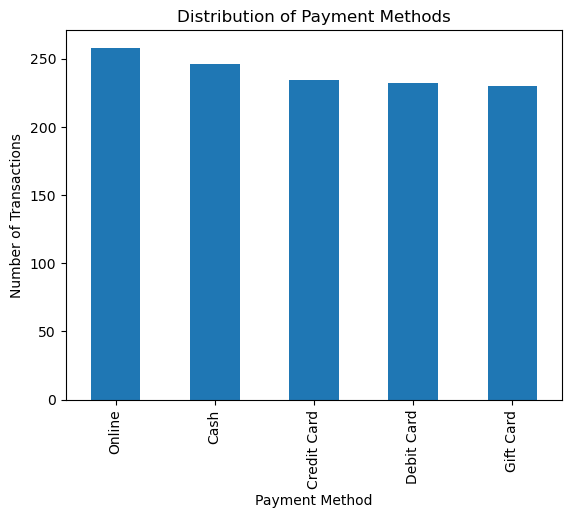

In [44]:
df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.show()

The bar chart indicates that online payment is the most frequently used payment method, followed by cash.
Credit card, debit card, and gift card payments are used at similar frequencies.
Overall, the distribution of payment methods is relatively even, suggesting that customers utilize a diverse range of payment
options with only a slight preference for online payments.

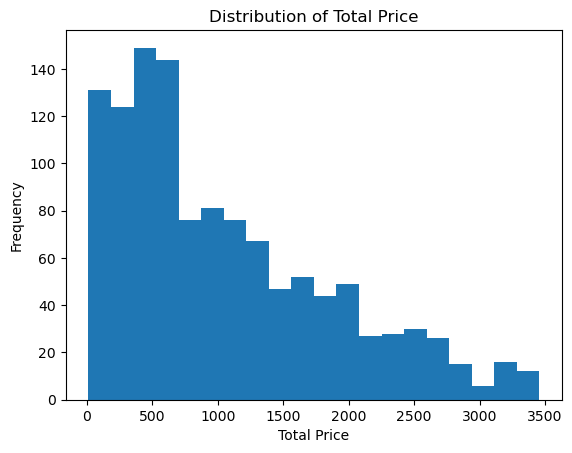

In [45]:
plt.hist(df["TotalPrice"], bins=20)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

# Interpretation of Total Price Distribution
The histogram indicates that the distribution of the Total Price is positively (right) skewed. 
Most customer orders fall within the lower Total Price range, as shown by the first four bars of the histogram 
(approximately 0–800).
These bars have the highest frequencies, indicating that the majority of customers placed low-value orders. 
After approximately 800, the frequency of orders gradually decreases, showing that fewer customers made higher-value purchases. This suggests that the e-commerce business processes a large number of lower-value orders and comparatively fewer high-value orders.

# Recommendation

Since lower-value orders occur more frequently than high-value orders, the business should implement strategies to increase the value of each transaction. This could include cross-selling complementary products, offering product bundles, and providing discounts or free shipping when customers reach a minimum spending threshold. These strategies may encourage customers to purchase more items and increase the average order value.

In [46]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [47]:
df["TotalPrice"] 

0       2853.10
1        302.70
2       2753.40
3        273.19
4       2504.04
         ...   
1195     107.04
1196    1325.06
1197     873.68
1198    1050.08
1199    2242.32
Name: TotalPrice, Length: 1200, dtype: float64

In [48]:
df["TotalPrice"].sum()

1264761.96

In [51]:
df.groupby("Product")["TotalPrice"].sum()

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

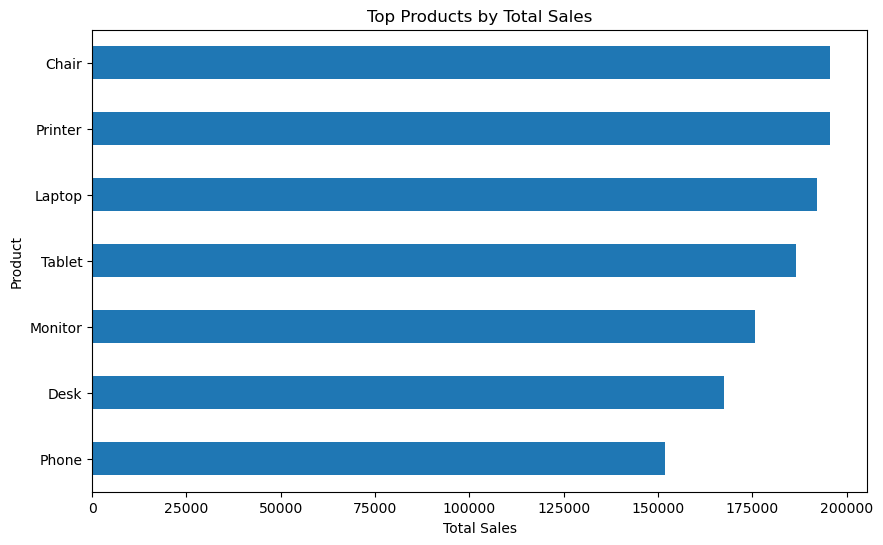

In [57]:
product_sales = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    
)

product_sales.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

The bar chart shows the top-selling products based on total sales revenue. 
Chair and Printer generated the highest total sales revenue, with both recording approximately 195,600. 
Laptop followed closely with total sales of about 192,000, while Tablet and Monitor also made significant contributions to 
overall sales. 

In contrast, Phone generated the lowest total sales revenue at approximately 152,000. Overall, Chair, Printer, and Laptop 
are the strongest-performing products based on total sales revenue.

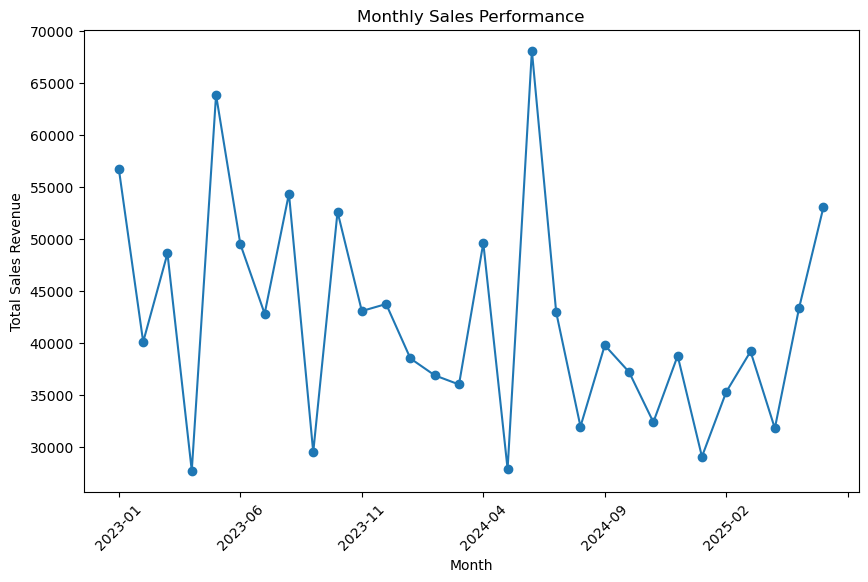

In [59]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["TotalPrice"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line", figsize=(10, 6), marker="o")

plt.title("Monthly Sales Performance")
plt.xlabel("Month")
plt.ylabel("Total Sales Revenue")
plt.xticks(rotation=45)
plt.show()

# Sales Revenue Shows Significant Monthly Fluctuations

The line chart shows the monthly sales performance of the e-commerce business from 2023 to 2025. 
Sales revenue fluctuated considerably throughout the period, indicating an inconsistent sales pattern. 
Several sharp increases and decreases can be observed. 
The highest monthly sales revenue was recorded around mid-2024 at approximately 68,000,
while the lowest sales revenue was approximately 28,000 was recorded in 2023, around April 2023.
Although sales declined during several periods, the chart shows an increase in sales revenue towards the end of the period. 
Overall, there is no clear continuous upward or downward trend, suggesting that the business experienced significant monthly 
variations in sales performance.

# Recommendation

The business should investigate the factors responsible for months with high sales revenue, such as promotions, seasonal demand,
or high-performing products, and apply successful strategies during lower-performing months. 
The business should also develop targeted marketing campaigns and promotional activities to improve sales consistency and reduce
significant monthly fluctuations.

In [63]:
df.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending=False)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

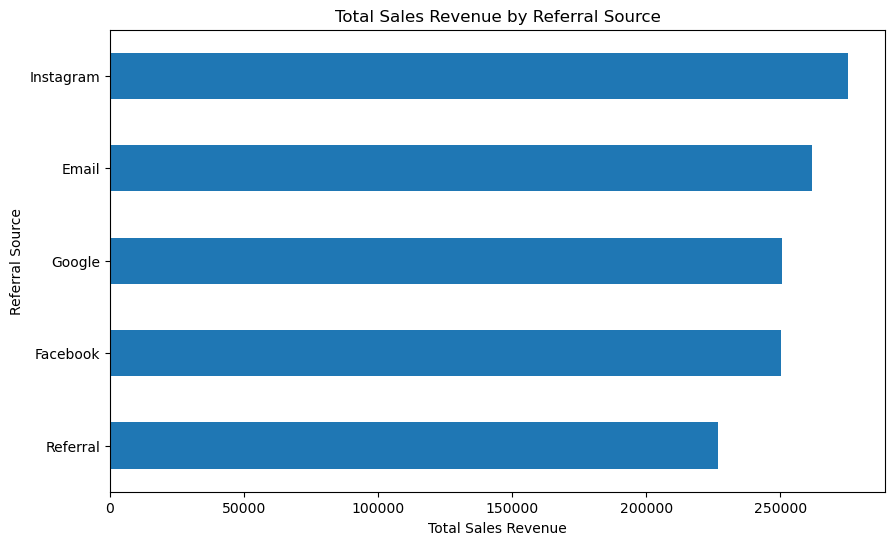

In [65]:
referral_sales = (
    df.groupby("ReferralSource")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

referral_sales.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Sales Revenue by Referral Source")
plt.xlabel("Total Sales Revenue")
plt.ylabel("Referral Source")
plt.show()

# Instagram Generates the Highest Sales Revenue
The bar chart shows the total sales revenue generated by different referral sources. 
Instagram generated the highest sales revenue at approximately 275,000, followed by Email at about 262,000.
Google and Facebook generated similar sales revenue of approximately 250,000. 
In contrast, Referral generated the lowest sales revenue at around 227,000. 
This indicates that Instagram is the most effective referral source in terms of total sales revenue generated, 
while Referral is the least effective.

# Recommendation
The business should prioritise and strengthen its marketing activities on Instagram, as it generates the highest sales revenue.
The business should also investigate the strategies used on Instagram and consider applying similar approaches
to lower-performing referral sources.
Additionally, the Referral channel should be reviewed and improved through referral incentives or reward programmes to increase
its effectiveness.

In [66]:
order_status = df["OrderStatus"].value_counts()


In [67]:
order_status

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

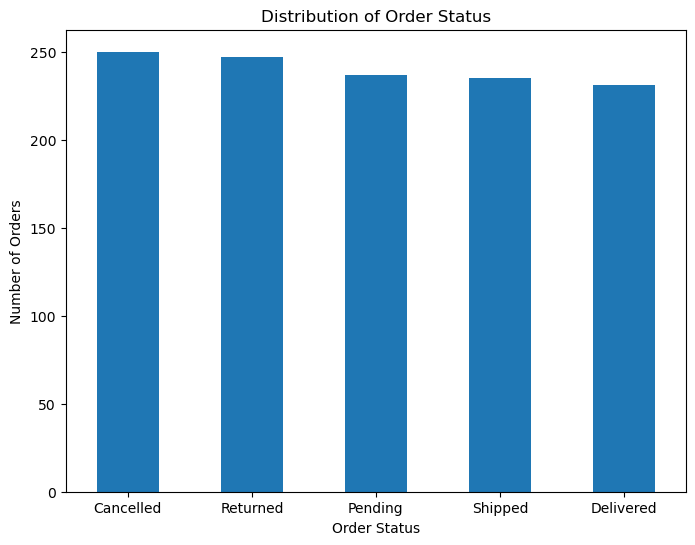

In [68]:
order_status = df["OrderStatus"].value_counts()

order_status.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

# Cancelled and Returned Orders Have the Highest Frequencies

The bar chart shows the distribution of orders across different order statuses. 
Cancelled orders recorded the highest frequency at approximately 250 orders, followed closely by returned orders at about 247. 
Pending and shipped orders accounted for approximately 237 and 235 orders, respectively, while delivered orders recorded 
the lowest frequency at about 231. Overall, the number of orders across the different statuses is relatively similar. 

However, the high number of cancelled and returned orders may indicate potential issues with the ordering process, 
product expectations, or customer satisfaction.

# Recommendation

The business should investigate the reasons for the high number of cancelled and returned orders. 
Customer feedback and return reasons should be analysed to identify common issues. 
Improving product descriptions, order fulfilment, product quality, and customer service may help reduce cancellations and 
returns and increase successful deliveries.

In [74]:
customer_orders = ( df.groupby("CustomerID").size().sort_values(ascending=False))

In [72]:
customer_orders

CustomerID
C35852    2
C94569    2
C97593    2
C14847    2
C91155    2
C98474    2
C70659    2
C38840    2
C46651    2
C56969    2
dtype: int64

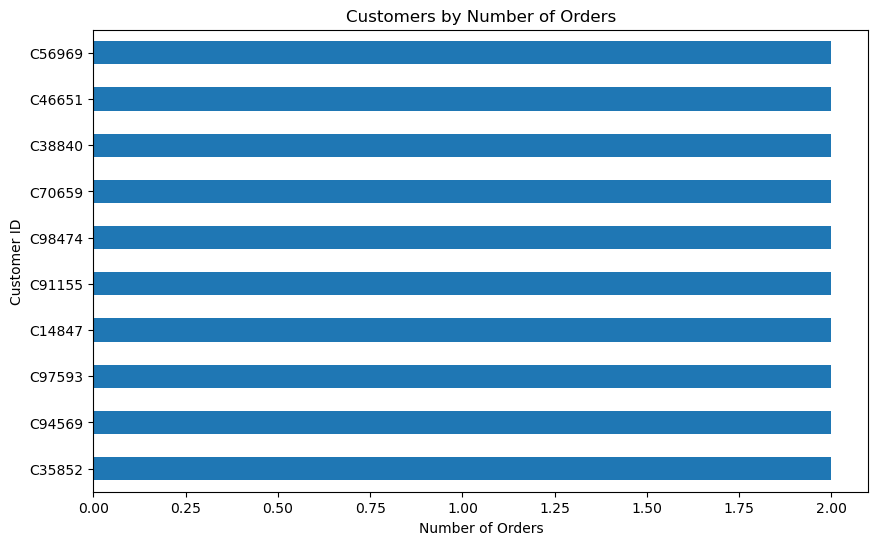

In [76]:
customer_orders = (
    df.groupby("CustomerID")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

customer_orders.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.show()

# Customers Recorded the Same Number of Orders
This bar chart does not clearly identify a single top customer because all the customers shown placed the same number of orders:
2 orders each, indicating that no single customer placed more orders than the others among the  customers. 

This suggests a similar purchasing frequency among these customers. However, the low number of repeat orders may indicate limited
repeat purchasing behaviour or customer retention.

# Recommendation

The business should implement customer retention strategies such as loyalty programmes, personalised offers, 
discounts for repeat purchases, and targeted email campaigns to encourage customers to place more orders.

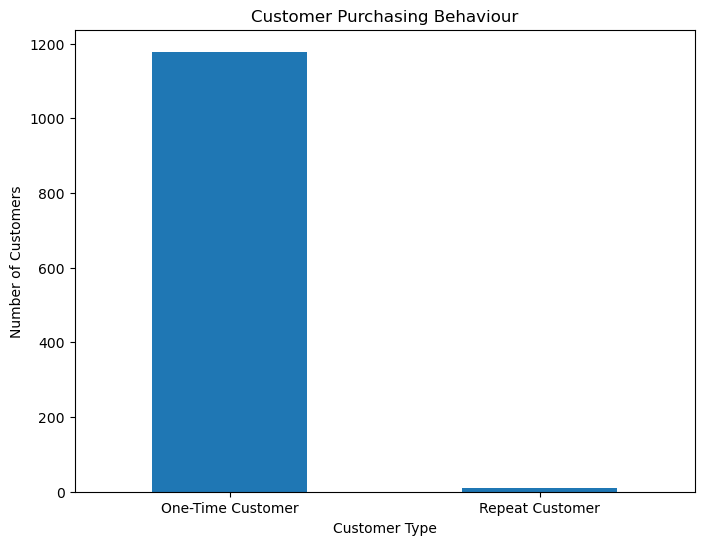

In [77]:
customer_orders = df.groupby("CustomerID").size()

customer_behavior = customer_orders.apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

customer_behavior.value_counts().plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Customer Purchasing Behaviour")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# The Business Has a Low Customer Retenion

The bar chart shows customer purchasing behaviour based on one-time and repeat purchases.
The majority of customers are one-time customers, with approximately 1,180 customers making only one purchase, 
while very few customers are repeat customers. 
This indicates a low level of repeat purchasing behaviour and suggests that the business may be experiencing challenges with 
customer retention.

# Recommendation

The business should focus on customer retention strategies to encourage repeat purchases. 
This can include loyalty programmes, personalised discounts, follow-up email campaigns, and special offers for returning 
customers. The business should also collect customer feedback to understand why most customers do not make repeat purchases.

 



# Overall Recommendation

The business should adopt a customer-focused sales strategy that prioritises customer retention, higher order values,
effective digital marketing, product optimisation, improved order fulfilment, and 
flexible payment options to achieve sustainable sales growth.